### HuyIGW04 - Twitter Sentiment Analysis - M05W01

In [184]:
# !gdown 1dANzxlEjeCEbveFOWWqzSG-niVx-vCgK

In [185]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from nltk.tokenize import TweetTokenizer
from collections import defaultdict 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [186]:
df = pd.read_csv('sentiment_analysis.csv', index_col='id')
df

,label,tweet
id,,
1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
2,0,Finally a transparant silicon case ^^ Thanks t...
3,0,We love this! Would you go? #talk #makememorie...
4,0,I'm wired I know I'm George I was made that wa...
5,1,What amazing service! Apple won't even talk to...
...,...,...
7916,0,Live out loud #lol #liveoutloud #selfie #smile...
7917,0,We would like to wish you an amazing day! Make...
7918,0,Helping my lovely 90 year old neighbor with he...


In [187]:
def text_normalization(text):
    # remove RT
    text = re.sub(r'^RT[\s]+', '', text)   

    # hastag removal
    text = re.sub(r'https?:\/\/.*[\n\r]*', '', text)

    # hyperlink & puntuation removal
    text = re.sub(r'[^\w\s]*', '', text)             #


    # tokenization
    tokenizer = TweetTokenizer(
        preserve_case=False,                        
        reduce_len=True,                             
        strip_handles=True                           
    )
    text = tokenizer.tokenize(text)
    return text

In [188]:
# chỉ một dataframe đã có thể tạo nên bộ từ điển hoàn chỉnh. label 1 là tích cực, label 0 là tiêu cực.
def vectorize(df):
    freq_dictionary = defaultdict(lambda: 0)
    for index, sample in df.iterrows():
        label = sample['label']
        text = sample['tweet']
        tokenizer = text_normalization(text)
        for token in tokenizer:
            pair = (token, label)
            freq_dictionary[pair] += 1
    
    return freq_dictionary

vectorization = vectorize(df)

# show some samples
list(vectorization.items())[:5]

[(('fingerprint', 0), 4),
 (('pregnancy', 0), 1),
 (('test', 0), 8),
 (('finally', 0), 168),
 (('a', 0), 727)]

In [189]:
# tạo ra vector Bag of Words: idx 0 là bias, idx 1 là freq của tích cực, 2 là freq của tiêu cực
# xử lý từng dòng một từ raw data.
def create_sample(input, freq):
    sample = np.zeros(3)
    sample[0] = 1                            # bias ở đầu luôn luôn là 1
    tokenizer = text_normalization(input)
    for token in tokenizer:
        sample[1] += freq[(token, 1)]         # chỉ số 1 là tích cực -> gắn với (token, 1)
        sample[2] += freq[(token, 0)]         # chỉ số 2 là tiêu cực -> gắn với (token, 0)

    return sample

# test với sample đầu tiên
freq = vectorize(df)
create_sample(df.iloc[50, 1], freq)

array([1.000e+00, 3.851e+03, 7.809e+03])

In [190]:
X = []
y = []
for index, sample in df.iterrows():
    label = sample.iloc[0]
    text = sample.iloc[1]
    sample = create_sample(text, freq)
    X.append(sample)
    y.append(label)

X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)

(7920, 3) (7920,)


In [191]:
# scaler
ss = StandardScaler()
X[:, 1:] = ss.fit_transform(X[:, 1:])
X[:5, :]

array([[ 1.00000000e+00, -1.30716137e+00, -1.68718472e+00],
       [ 1.00000000e+00,  7.50480838e-02, -2.07529581e-01],
       [ 1.00000000e+00, -6.01172836e-01,  4.79383462e-05],
       [ 1.00000000e+00,  2.56134390e-01,  4.73040816e-01],
       [ 1.00000000e+00,  1.78321289e+00,  8.11551847e-01]])

In [192]:
# train:val:test = 7:2:1
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.125, random_state=42, shuffle=True)

print('train size:', X_train.shape[0])
print('val size:', X_val.shape[0])
print('test size:', X_test.shape[0])

train size: 5544
val size: 1584
test size: 792


In [193]:
N = X.shape[1]
theta = np.random.random(N)
theta

array([0.91072323, 0.67063508, 0.47373703])

In [194]:
def compute_linear(input, theta):
    return input@theta 

def compute_predict(input, theta):
    z = compute_linear(input, theta)
    y_pred = 1/(1+np.exp(-z))
    return y_pred

def compute_loss(prediction, true_label):
    N = true_label.shape[0]
    loss = np.mean(- true_label*np.log(prediction) - (1-true_label)*np.log(1 - prediction))
    return loss

def derivative(x, y_pred, y_true):
    N = x.shape[1]
    return (1/N)*(x.T)@(y_pred - y_true)

def update_weight(weight, dl, lr=0.005):
    weight = weight - dl*lr
    return weight

def compute_accuracy(X, y, theta, threshold=0.5):
    y_pred = compute_predict(X, theta)
    y_pred = (y_pred >= threshold)
    accuracy = (y == y_pred).mean()
    return accuracy

In [195]:
# epoch training 
epoch = 100
batch_size = 16
N = X_train.shape[0]
loss_train = []
acc_train = []
loss_val = []
acc_val = []


for i in range(epoch):
    losses = []
    acc_train_epoch = []
    losses_val = []
    acc_val_epoch = []
    for i in range(0,N,batch_size):
        x_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]
        y_pred_i = compute_predict(x_i, theta)
        loss_batch = compute_loss(y_pred_i, y_i)
        losses.append(loss_batch)
        dl = derivative(x_i, y_pred_i, y_i)
        theta = update_weight(theta, dl)

        # training accuracy - batch implementation
        acc = compute_accuracy(x_i, y_i, theta)
        acc_train_epoch.append(acc)

        # validation loss - theta checking after batch train
        y_pred_val = compute_predict(X_val, theta)
        loss_val_batch = compute_loss(y_pred_val, y_val)
        losses_val.append(loss_val_batch)

        # validation accuracy
        acc_val_batch = compute_accuracy(X_val, y_val, theta)
        acc_val_epoch.append(acc_val_batch)

    # training loss
    loss_epoch = sum(losses)/len(losses)  
    loss_train.append(loss_epoch)     

    # training accuracy   
    acc_epoch_i = sum(acc_train_epoch)/len(acc_train_epoch)
    acc_train.append(acc_epoch_i)

    # validation loss
    loss_val_i = sum(losses_val)/len(losses_val)
    loss_val.append(loss_val_i)

    # validation accuracy
    acc_val_i = sum(acc_val_epoch)/len(acc_val_epoch)
    acc_val.append(acc_val_i)

Text(0, 0.5, 'Loss')

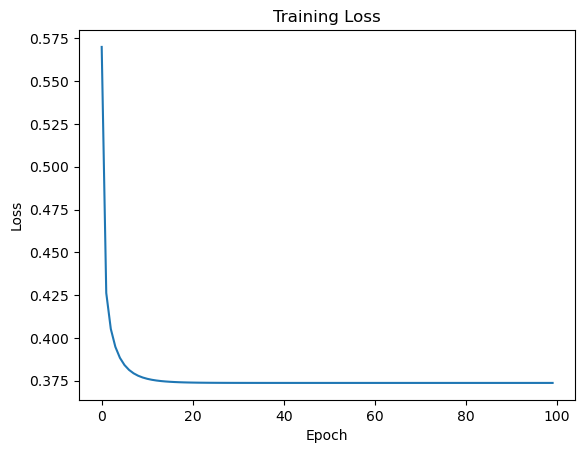

In [196]:
plt.plot(loss_train)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

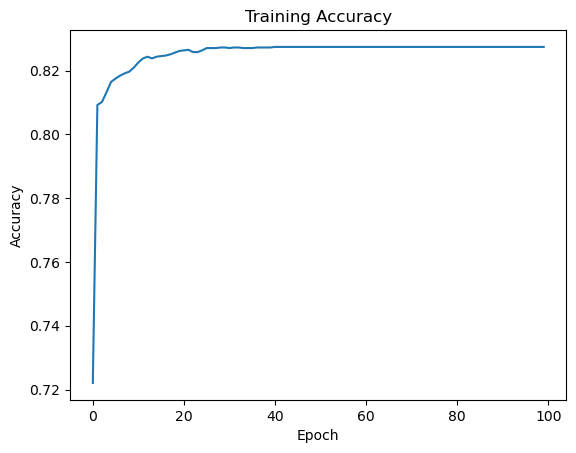

In [197]:
plt.plot(acc_train)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

Text(0, 0.5, 'Loss')

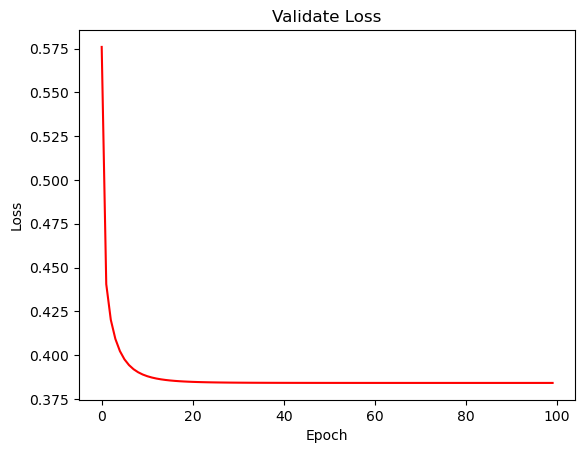

In [198]:
plt.plot(loss_val, color='red')
plt.title('Validate Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Accuracy')

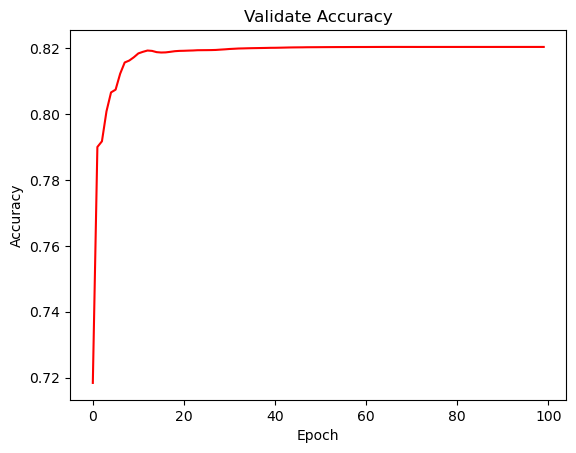

In [199]:
plt.plot(acc_val, color='red')
plt.title('Validate Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

In [200]:
test_acc = compute_accuracy(X_test, y_test, theta)
print('Evoluation on validation and test set:')
print('Accuracy for test set: {}'.format(test_acc.round(4)))

Evoluation on validation and test set:
Accuracy for test set: 0.8422


### inference function

In [201]:
def prediction(text):
    vectorization = create_sample(text, freq)
    vectorization = vectorization.reshape(1, 3)
    predict = compute_predict(vectorization, theta)
    label = 0 if predict < 0.5 else 1
    return label

prediction("In other news, my iPod has developed yet another fault. >.< #ipoo")

1